In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#读取并处理数据（完全沿用你现在的正确代码）
data = pd.read_csv("housing.csv")
data = data.select_dtypes(include=[np.number])  #只留数值，删掉所有文本列
data = data.dropna()
data.rename(columns={'median_house_value': '房价'}, inplace=True)

#构造特征、标签
X = data.drop('房价', axis=1)
y = data['房价']

#划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

In [2]:
class RidgeRegression:
    #初始化
    def __init__(self, alpha=0.1):
        self.w = None  #权重
        self.b = None  #偏置
        self.alpha = alpha  #增加了岭回归的正则化系数
        #训练模型
    def fit(self, x_data, y_data):
        #转为numpy数组
        x = np.array(x_data)
        y = np.array(y_data)
        ones = np.ones((x.shape[0], 1))
        x_new = np.hstack((ones, x))
        #岭回归方程 
        xtx = np.dot(x_new.T, x_new)
        #在这里加了一个正则项 alpha*I，I是单位矩阵，且不对偏置项b做正则化
        n_features = xtx.shape[0]
        I = np.eye(n_features)
        I[0, 0] = 0  #不对偏置项（第0项）做正则化，只惩罚权重
        xtx_reg = xtx + self.alpha * I
        xty = np.dot(x_new.T, y)
        theta = np.dot(np.linalg.inv(xtx_reg), xty)
        self.b = theta[0]
        self.w = theta[1:]
 #预测函数
    def predict(self, x_data):
        x = np.array(x_data)
        pre = self.b + np.dot(x, self.w)
        return pre

========== 岭回归（alpha=0.1）结果 ==========
训练集均方误差MSE：4831833032.83
测试集均方误差MSE：4885988833.94
测试集决定系数R²：0.6297


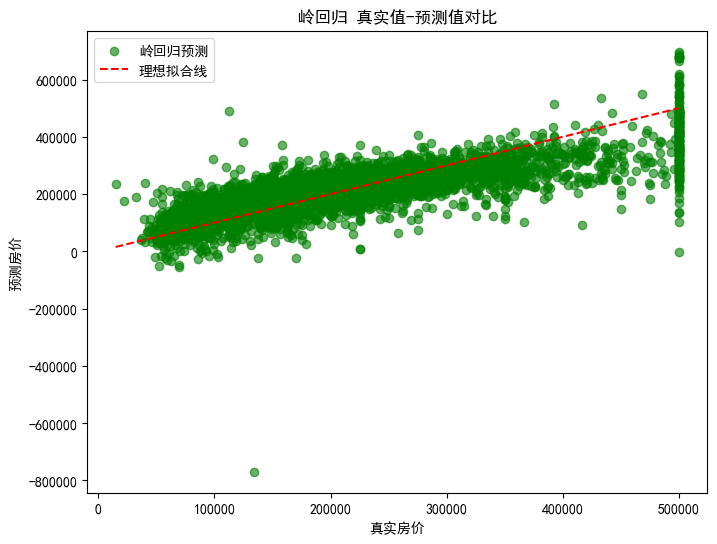

In [3]:
#训练岭回归模型
ridge_model = RidgeRegression(alpha=0.1) 
ridge_model.fit(X_train, y_train)

#预测
y_train_pre_ridge = ridge_model.predict(X_train)
y_test_pre_ridge = ridge_model.predict(X_test)

#模型评价
print("========== 岭回归（alpha=0.1）结果 ==========")
print(f"训练集均方误差MSE：{mean_squared_error(y_train, y_train_pre_ridge):.2f}")
print(f"测试集均方误差MSE：{mean_squared_error(y_test, y_test_pre_ridge):.2f}")
print(f"测试集决定系数R²：{r2_score(y_test, y_test_pre_ridge):.4f}")

#可视化
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pre_ridge, color='green', alpha=0.6, label='岭回归预测')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='理想拟合线')
plt.xlabel("真实房价")
plt.ylabel("预测房价")
plt.title("岭回归 真实值-预测值对比")
plt.legend()
plt.show()